<a id="0"></a> <br>
 # Table of Contents  
 To be completed
1. [Compute Absorption Cross-Section](#1)     
    1.1 [Fetch our molecules](#2) \
    1.2 [Compute tau] (#3) \
   



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.modeling.models import BlackBody
from astropy import units as u
from astropy import constants as const
import os

from atmosphere_functions import *

from hapi import * # pip install hapi

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
path = '~/Documents/M2Classes/Radiative/Transit_Project/'

### **Choose the wavelength range we want**

In [3]:
# Choose the wavelength range we want 
lambda_min = 0.5 #micrometers
lambda_max = 5  #micrometers

<a id="2"></a> 
## Ⅰ. Fetch our molecules 
Create a local database directory (if it exists then skip fetching of the data) 

In [4]:
# Initialize database directory
db_dir = 'hitran_db_CO2'
os.makedirs(db_dir, exist_ok=True)
db_begin(db_dir)

# Name of the table you want to fetch locally
lambda_min_str = str(lambda_min).replace('.', '_')
lambda_max_str = str(lambda_max).replace('.', '_')

table_name = f"CO2_{lambda_min_str}um_{lambda_max_str}um"
print(table_name)

# -----------------------------------------------------
# 1. Check if the table already exists in the database
# -----------------------------------------------------
existing_tables = tableList()  # HAPI’s official list of local tables

if table_name not in existing_tables:
    print(f"Table '{table_name}' not found locally. Fetching from HITRAN...")
    # wavenumbers in cm⁻¹
    wavenumber_min = 1/(lambda_max*1e-4) # wavenumbers in cm⁻¹
    wavenumber_max = 1/(lambda_min*1e-4) 
    print(f"Extracting table from k_min = {wavenumber_min} cm⁻¹ to k_max = {wavenumber_max} cm⁻¹")
    fetch(table_name, 2, 1, wavenumber_min, wavenumber_max)   # downloads ONLY if missing
else:
    print(f"Table '{table_name}' already exists locally. Skipping fetch.")
    
# -----------------------------------------------------
# 2. Load the data normally
# -----------------------------------------------------
nu, A, elower, gp, gpp = getColumns(
    table_name,
    ['nu', 'A', 'elower', 'gp', 'gpp']
)

df = pd.DataFrame({
    'nu': nu,
    'A': A,
    'elower': elower,
    'gp': gp,
    'gpp': gpp
})

print(df.head())


Using hitran_db_CO2

CO2_0_5um_5um
                     Lines parsed: 133038
CO2_0_5um_5um
Table 'CO2_0_5um_5um' already exists locally. Skipping fetch.
            nu         A     elower    gp   gpp
0  2000.114112  0.000018  1512.6365  93.0  93.0
1  2000.231253  0.000020  2293.8868  99.0  99.0
2  2000.273283  0.013370  3864.6513  49.0  51.0
3  2000.297745  0.000095  1346.8814   9.0  11.0
4  2000.332876  0.000234  2688.2234  11.0  13.0


### Helper: Line Profile Formulas

**Gaussian profile**
$$ 
G(\nu) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left[-\frac{1}{2}\left(\frac{\nu - \nu_0}{\sigma}\right)^2\right]
$$

**Lorentz profile**
$$
L(\nu) = \frac{\delta}{\pi \left[(\nu - \nu_0)^2 + \delta^2\right]}
$$

**Voigt profile**
$$
V(\nu) = \frac{\Re\!\left[\, w\!\left(\frac{\nu - \nu_0 + i\delta}{\sigma\sqrt{2}} \right) \right]}{\sigma\sqrt{2\pi}}
$$
where \( w(z) \) is the Faddeeva function:
$$
w(z) = e^{-z^2}\,\operatorname{erfc}(-iz).
$$


In [5]:
from scipy.special import wofz

def gaussian_profile(sigma,center,frequency):
    return((1/(sigma*np.sqrt(2*np.pi)))* np.exp(-0.5*((frequency-center) / sigma)**2))

def lorentz_profile(delta, center, frequency):
    return delta / (np.pi * ((frequency-center)**2 + delta**2))

def voigt_profile(sigma,delta,center,frequency):
    return((np.real(wofz(((frequency-center) + 1j * delta) / (sigma * np.sqrt(2)))))/ (sigma * np.sqrt(2 * np.pi)))

## Ⅱ. Planet Constants

In [6]:
# Planet Parameters
T_atm = 900 + 273
M_p = 0.28 * const.M_jup.value 
R_p = 1.27 * const.R_jup.value 
P0 = 1e6  
R_star = 0.895*const.R_sun.value

---------------------

## Ⅲ. Extracting Energy Levels and Populations

### 1. **Lower and upper energy levels**  
   - The HITRAN data contains the lower state energy (`elower`) for each transition.  
   - The upper state energy is calculated as $ E_\text{upper} = E_\text{lower} + h c \tilde{\nu} $, where $\tilde{\nu}$ is the transition wavenumber in cm⁻¹.

### 2. **Degeneracies**  
   - Each energy level has a degeneracy \( g \) (statistical weight), coming from `gpp` for lower levels and `gp` for upper levels.  
   - Degenerate levels are merged so that each unique combination of energy and degeneracy appears only once.


In [7]:
levels_lower = pd.DataFrame({
    'E': df['elower'],
    'g': df['gpp'],
    'label': 'lower'
})
levels_upper = pd.DataFrame({
    'E': df['elower'] + df['nu'],
    'g': df['gp'],
    'label': 'upper'
})

# Combine and remove duplicates
levels_all = pd.concat([levels_lower, levels_upper], ignore_index=True)
levels_unique = levels_all.drop_duplicates(subset=['E', 'g']).sort_values(by='E').reset_index(drop=True)

### 3. **Conversion to SI units**  
   - HITRAN energies are in cm⁻¹. They are converted to Joules using the equivalency between spectral units and energy:  
     $$
     E_J = h c \, E_\text{cm}^{-1}
     $$

In [8]:
E_cm = levels_unique['E'].values*(1/u.cm) 
E_J = E_cm.to(u.J, equivalencies=u.spectral()) 

energy_levels = E_J.value
degeneracies = levels_unique['g'].values

### 4. **Radiative lifetime of an upper level**  
For each upper energy level $u$, the radiative lifetime $\tau_u$ is defined as

$$ \tau_u = \frac{1}{\sum_i A_{u \to i}} $$

where:
- $A_{u \to i}$ is the Einstein coefficient for spontaneous emission from the upper level $u$ to a lower level $i$,
- the sum runs over all radiative transitions originating from level $u$.

Thus $\tau_u$ represents the characteristic time the system spends in level $u$ before decaying radiatively.


In [9]:
df['E_u'] = df['elower'] + df['nu']   # still in cm^-1 units

# Sum A-values for each upper level
A_sum_by_Eu = df.groupby('E_u')['A'].sum()

# tau_u = 1 / Σ A
tau_u = 1 / A_sum_by_Eu

# Build dataframe
tau_df = tau_u.reset_index()
tau_df.columns = ['E_u', 'tau_u']

# Merge into df
df = df.merge(tau_df, on='E_u', how='left')

In [10]:
df

,nu,A,elower,gp,gpp,E_u,tau_u
0,2000.114112,1.765000e-05,1512.6365,93.0,93.0,3512.750612,5.665722e+04
1,2000.231253,1.965000e-05,2293.8868,99.0,99.0,4294.118053,5.089059e+04
2,2000.273283,1.337000e-02,3864.6513,49.0,51.0,5864.924583,7.479432e+01
3,2000.297745,9.455000e-05,1346.8814,9.0,11.0,3347.179145,1.057641e+04
4,2000.332876,2.337000e-04,2688.2234,11.0,13.0,4688.556276,4.278990e+03
...,...,...,...,...,...,...,...
133033,19903.068715,7.090000e-09,81.9401,31.0,29.0,19985.008815,7.213966e+07
133034,19904.430476,7.151000e-09,106.1297,35.0,33.0,20010.560176,1.398406e+08
133035,19905.754254,7.436000e-09,133.4393,39.0,37.0,20039.193554,6.817562e+07
133036,19907.023217,7.856000e-09,163.8684,43.0,41.0,20070.891617,6.428801e+07


---
## Ⅳ. Computing Absorption Cross-Section

We compute the absorption cross-section of molecules as a function of frequency using either **Gaussian (Doppler)** or **Voigt** profiles. The total absorption at each frequency is then summed over all transitions.

### 1. **Frequency Grid**
We define a frequency array corresponding to the wavelength range of interest:

$$
\nu_\text{array} = \text{linspace}\left(\frac{c}{\lambda_\text{max}}, \frac{c}{\lambda_\text{min}}, N \right)
$$

where \(c\) is the speed of light, $\lambda_\text{min}$ and $\lambda_\text{max}$ define the wavelength range, and \(N\) is the number of points.

---

**The choice of frequency (or wavenumber) grid is not arbitrary — it must resolve the spectral lines properly, otherwise you either miss absorption peaks or miscompute the integrated cross-section.**


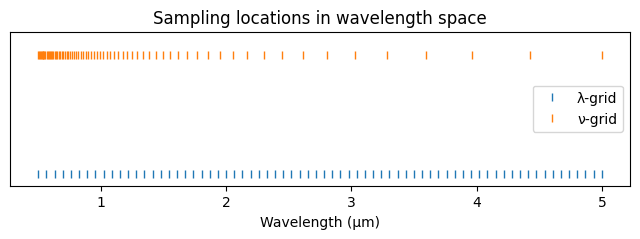

In [11]:
lambda_grid = np.linspace(lambda_min, lambda_max, 70) * 1e-6
freq_grid_from_lambda = const.c.value / lambda_grid

freq_grid = np.linspace(const.c.value/(lambda_max*1e-6),
                        const.c.value/(lambda_min*1e-6),
                        70)
lambda_grid_from_freq = const.c.value / freq_grid

plt.figure(figsize=(8,2))
plt.plot(lambda_grid*1e6, np.zeros_like(lambda_grid), '|', label="λ-grid")
plt.plot(lambda_grid_from_freq*1e6, np.ones_like(lambda_grid_from_freq), '|', label="ν-grid")
plt.yticks([])
plt.xlabel("Wavelength (µm)")
plt.legend()
plt.title("Sampling locations in wavelength space")
plt.ylim((-0.1,1.2))
plt.show()


In [84]:
N_freq   = 20000
N_lambda = 20000
lambda_min, lambda_max = 0.5, 5
freq_array = np.linspace(const.c.value/(lambda_max*1e-6),
                        const.c.value/(lambda_min*1e-6),
                        N_freq)
lambda_array = (const.c.value/freq_array)*1e6

### 2. **Total Absorption Cross-Section**
For each transition \(i\), the absorption cross-section contribution is:

$$
\sigma_i(\nu) = \frac{g_i}{g_j} \frac{c^2}{8 \pi \nu_0^2} A_{ij} \, \phi(\nu)
$$

where $ g_i $ and $ g_j $ are degeneracies of upper and lower levels, $ A_{ij} $ is the Einstein coefficient, and $ \phi(\nu) $ is the line profile (Gaussian or Voigt).  

The **total absorption cross-section** is then summed over all transitions:

$$
\sigma_\text{total}(\nu) = \sum_i \sigma_i(\nu)
$$

---

In [44]:
nu = df['nu'].values*(1/u.cm)
print(len(nu))

133038


In [82]:
def compute_total_absorption(df, freq_array, T_atm, Mm = 44, line_profile='voigt'):

    ## UNITS : nu = cm-1, A = s-1, elower = cm-1
    elower = df['elower'].values*(1/u.cm)
    nu = df['nu'].values*(1/u.cm)
    eupper = elower + nu

    nu = nu.to(u.Hz, equivalencies=u.spectral())     # convert cm−1 → Hz
    elower = elower.to(u.J, equivalencies=u.spectral())
    eupper = eupper.to(u.J, equivalencies=u.spectral())

    tau_lorentz = df['tau_u'].values*(u.s)

    total_absorption_sigma = np.zeros(len(freq_array))

    for i in range(len(nu)):

        if line_profile == 'gaussian':
            width = (nu[i].value/const.c.value)*np.sqrt(const.k_B.value * T_atm / (Mm/(1000 * const.N_A.value)))
            sigma0 = 1/(np.sqrt(np.pi)*width)
            
            profile = absorption_cross_section(nu[i].value, width, sigma0, freq_array)

        if line_profile == 'voigt':
            sigma = (nu[i].value/const.c.value)*np.sqrt((const.k_B.value * T_atm) / (Mm/(1000 * const.N_A.value)))
            center = nu[i].value
            delta = 1 / (4 * np.pi * tau_lorentz[i].value)
            
            profile = voigt_profile(sigma, delta, center, freq_array)

        total_absorption_sigma += (df['gp'][i]/df['gpp'][i])*(const.c.value**2/(8*np.pi*nu[i].value**2))*df['A'][i]*profile

    return total_absorption_sigma

total_absorption_sigma_voigt = compute_total_absorption(df, freq_array, T_atm, line_profile='voigt')
total_absorption_sigma_gaussian = compute_total_absorption(df, freq_array, T_atm, line_profile='gaussian')

/tmp/ipykernel_290521/1445017020.py:16: RuntimeWarning: divide by zero encountered in divide
  return const.c.value / f * 1e6 # microns


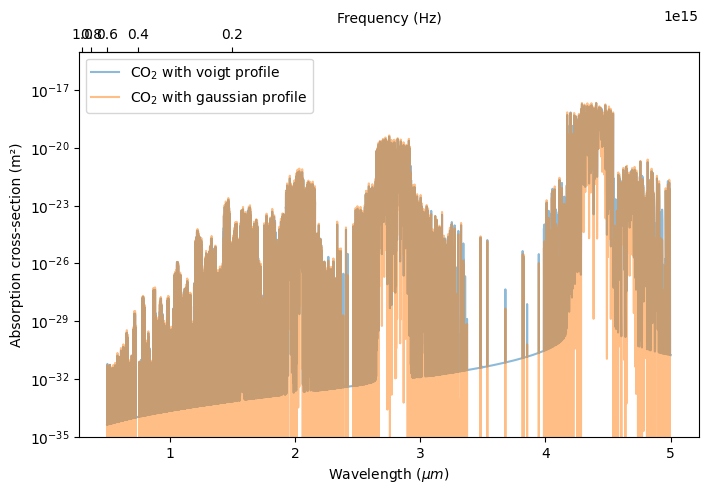

In [101]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(lambda_array, total_absorption_sigma_voigt, label='CO$_2$ with voigt profile', alpha = 0.5)
ax1.plot(lambda_array, total_absorption_sigma_gaussian, label='CO$_2$ with gaussian profile', alpha = 0.5 )

ax1.set_xlabel(r'Wavelength ($\mu m$)')

ax1.set_ylabel('Absorption cross-section (m²)')
ax1.set_yscale('log')
ax1.set_ylim(1e-35,1e-15)

ax1.legend()

# wavelength axis on top
def freq_to_wavelength_um(f):
    return const.c.value / f * 1e6 # microns

def wavelength_um_to_freq(l):
    return const.c.value / (l *1e-6)

ax2 = ax1.secondary_xaxis(
    'top',
    functions=(wavelength_um_to_freq, freq_to_wavelength_um)
)
ax2.set_xlabel('Frequency (Hz)')

# ax2.set_xlim(0.65e14, 0.71e14)
plt.show()

### **Choose which line profile you want**


In [65]:
total_absorption_sigma = total_absorption_sigma_voigt

## Ⅴ. About the Scale Height
The **scale height** of an isothermal atmosphere is:

$$
H_0 = \frac{k_B T_\mathrm{atm}}{ \mu m_\mathrm{H} g }
$$


We include a **scaling factor** $H_\mathrm{factor}$ to adjust the scale height:

$$
H = H_\mathrm{factor} \cdot H_0
$$

This is useful to simulate a more extended or compressed atmosphere for testing or visualization.


---
#### 1. **Diffusive equilibrium (no mixing)**:
   
Each species follows its own hydrostatic balance:

$$ \frac{dp_i}{dz} = -n_i m_i g \quad \Rightarrow \quad n_i(z) = n_i(0), \exp\Big(-\frac{m_i g z}{k_B T}\Big) $$

Scale height of species $i$:

$$ H_i = \frac{k_B T}{m_i g} $$

Heavier species fall off faster with altitude; straight lines on $\ln n_i$ vs $z$ plot with different slopes.

---

#### 2. **Well-mixed atmosphere (turbulent mixing dominates)**:
   
Constant mixing ratio $x_i = n_i / n_{\rm tot}$:

$$ n_i(z) = x_i, n_{\rm tot}(z) = n_i(0), \exp\Big(-\frac{\bar m g z}{k_B T}\Big) $$

Mean molecular mass: $ \bar m = \sum_i x_i m_i $

All species have the same scale height $$H_{\rm mean} = \frac{k_B T}{\bar m g}$$

straight lines on $\ln n_i$ vs $z$ plot are parallel.

In [109]:
Z = partition_function(energy_levels, degeneracies, T_atm)

In [110]:
H_factor=2
Mm = 44
Mm_bulk = 2.3

H_CO2 = scale_height(T_atm, Mm, M_p, R_p)
H_bulk = scale_height(T_atm, Mm_bulk, M_p, R_p)

print(f"If Mm = {Mm} then H = {scale_height(T_atm, Mm, M_p, R_p)}")
print(f"If Mm = {Mm_bulk} then H = {scale_height(T_atm, Mm_bulk, M_p, R_p)}")

If Mm = 44 then H = 51140.467820059865
If Mm = 2.3 then H = 978339.384383754


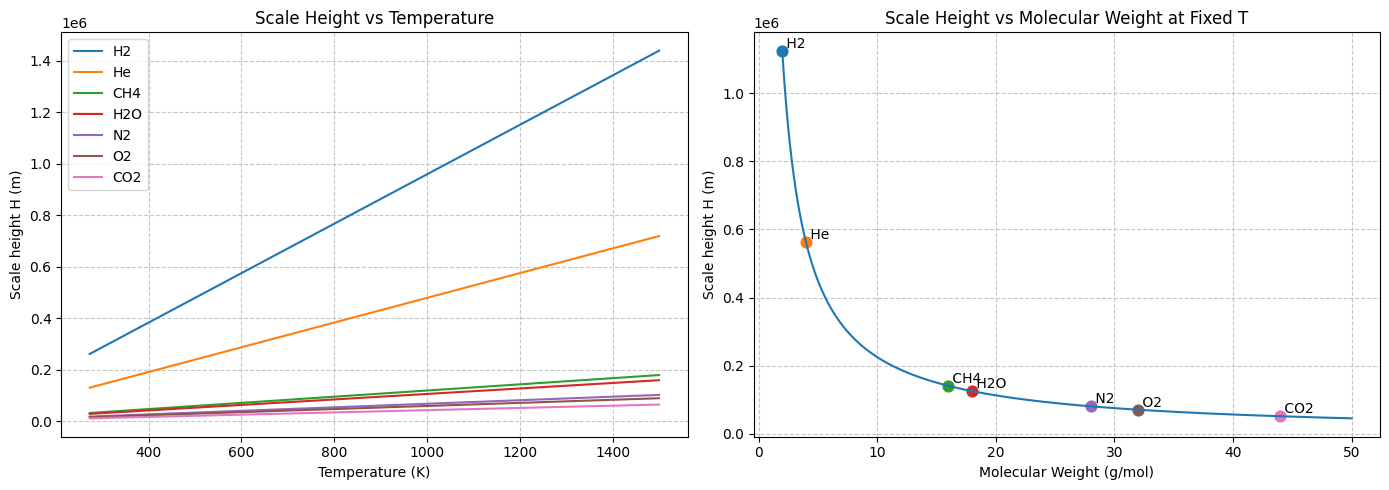

In [111]:
T_array = np.linspace(273, 1500, 300)    # temperature grid
Mm_array = np.linspace(2, 50, 300)       # molecular weight grid (g/mol)

molecules = {
    "H2" : 2,
    "He" : 4,
    "CH4": 16,
    "H2O": 18,
    "N2" : 28,
    "O2" : 32,
    "CO2": 44,
}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

for name, Mm_i in molecules.items():
    ax1.plot(T_array, scale_height(T_array, Mm_i, M_p, R_p),
             label=f"{name}")

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Scale height H (m)")
ax1.set_title("Scale Height vs Temperature")
ax1.grid(linestyle='--', alpha = 0.7)
ax1.legend()

T0 = T_atm  # fixed temperature
H_vals = scale_height(T0, Mm_array, M_p, R_p)

ax2.plot(Mm_array, H_vals, label=f"T = {T0} K")

for name, Mm_i in molecules.items():
    H_mol = scale_height(T0, Mm_i, M_p, R_p)
    ax2.scatter(Mm_i, H_mol, s=60)
    ax2.text(Mm_i, H_mol, f" {name}", verticalalignment='bottom')

ax2.set_xlabel("Molecular Weight (g/mol)")
ax2.set_ylabel("Scale height H (m)")
ax2.set_title("Scale Height vs Molecular Weight at Fixed T")
ax2.grid(linestyle='--', alpha = 0.7)

plt.tight_layout()
plt.show()

## Ⅵ. Computing tau

We are computing the **transmission spectrum of CO₂** assuming a **constant atmospheric temperature**.

### 1. **Atmospheric density profile**  

We assume an isothermal atmosphere:

$$
n(z) = n_0 \exp\left(-\frac{z}{H}\right)
$$

where \(H\) is the scale height, \(z\) is the altitude, and \(n_0\) is the density at the surface.

---

### 2. **Population of energy levels**  

Each level is populated according to the Boltzmann distribution:

$$
n_i(z) = n(z) \frac{g_i e^{-E_i / (k_B T)}}{Z(T)}
$$

where \(g_i\) is the degeneracy, \(E_i\) the energy in Joules, \(Z(T)\) the partition function, and \(n(z)\) the local density.  

The **total CO₂ number density** is:

$$
n_\mathrm{CO2}(z) = \sum_i n_i(z)
$$


In [117]:
n_CO2 = []
zmax = 10*H_bulk # height at which we consider atmosphere to be 0
z = np.arange(0, zmax, 1e4)
print("zmax =", zmax)

for i in range(len(z)):
    n_z = density_profile_atm_consT(z[i], T_atm, H_CO2, P0)
    n_total_array = energy_level_density(energy_levels, degeneracies, T_atm, Z, n_z) 
    n_total = np.sum(n_total_array)
    n_CO2.append(n_total)


zmax = 9783393.84383754


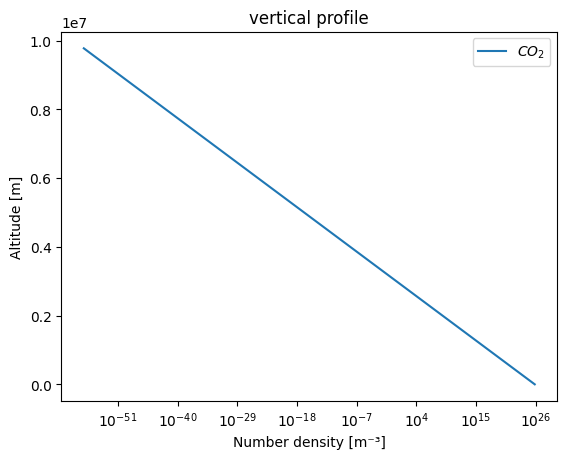

In [118]:
plt.figure()
plt.plot(n_CO2, z, label = r'$CO_2$')

plt.gca().invert_yaxis()
plt.xlabel('Number density [m⁻³]')
plt.ylabel('Altitude [m]')
plt.xscale('log')
plt.gca().invert_yaxis() 
plt.title(f'vertical profile')
plt.legend()
plt.show()

### 3. **Optical depth and transmission**  

The optical depth at frequency $\nu$ is:

$$
\tau_\nu(z) = \sigma_\nu \, n_\mathrm{CO2}(z) \, \sqrt{2 \pi (R_p + z) \color{blue}{H}}
$$

Transmission:

$$
T_\nu(z) = \exp(-\tau_\nu(z))
$$

---

### 4. **Effective radius and transit depth**  

The effective transit radius is:

$$
R_\mathrm{eff}^2(\nu) = R_p^2 + 2 \int_0^{\color{blue}{z_\mathrm{max}}} (1 - T_\nu(z)) (R_p + z) dz
$$

The normalized transit depth:

$$
\delta_\nu = \frac{R_\mathrm{eff}^2(\nu)}{R_\star^2}
$$

In [119]:
n_CO2 = np.array(n_CO2)
delta_nu = []

for i in range(len(total_absorption_sigma)):
    T_nu = []
    for j in range(len(z)):
        tau_nu = total_absorption_sigma[i]*n_CO2[j]*np.sqrt(2*np.pi*(z[j] + R_p)*H_CO2) # trusting Lellouch slide 66
        T_nu.append(np.exp(-np.array(tau_nu)))
    T_nu = np.array(T_nu)
    R_eff2 = R_p**2 + 2 * np.trapezoid((1 - T_nu) * (z + R_p), z + R_p)
    delta_nu.append(R_eff2 / R_star**2)


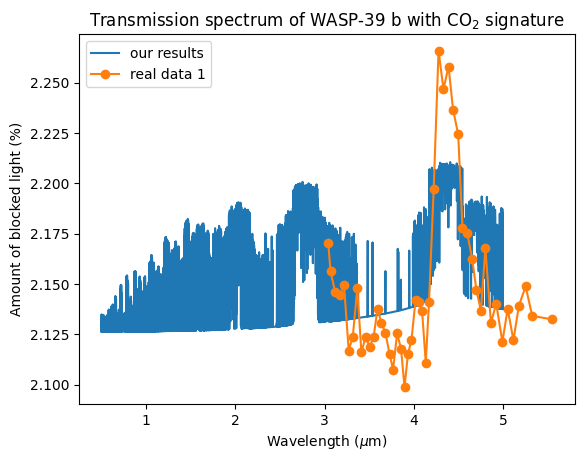

In [120]:
lambda_array = (const.c.value/freq_array)*1e6
y = np.array(delta_nu)*100
# binned_data = fast_binning(lambda_array, y, 0.05)
observed_data = pd.read_csv('WASP39b_data.csv')
observed_x = observed_data.iloc[:,0]
observed_y = observed_data.iloc[:,1]

plt.figure()
plt.plot(lambda_array, y, label='our results')
# plt.plot(lambda_array, y, label='not binned')
plt.plot(observed_x, observed_y, 'o-', label='real data 1')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
plt.show()

20000
20000


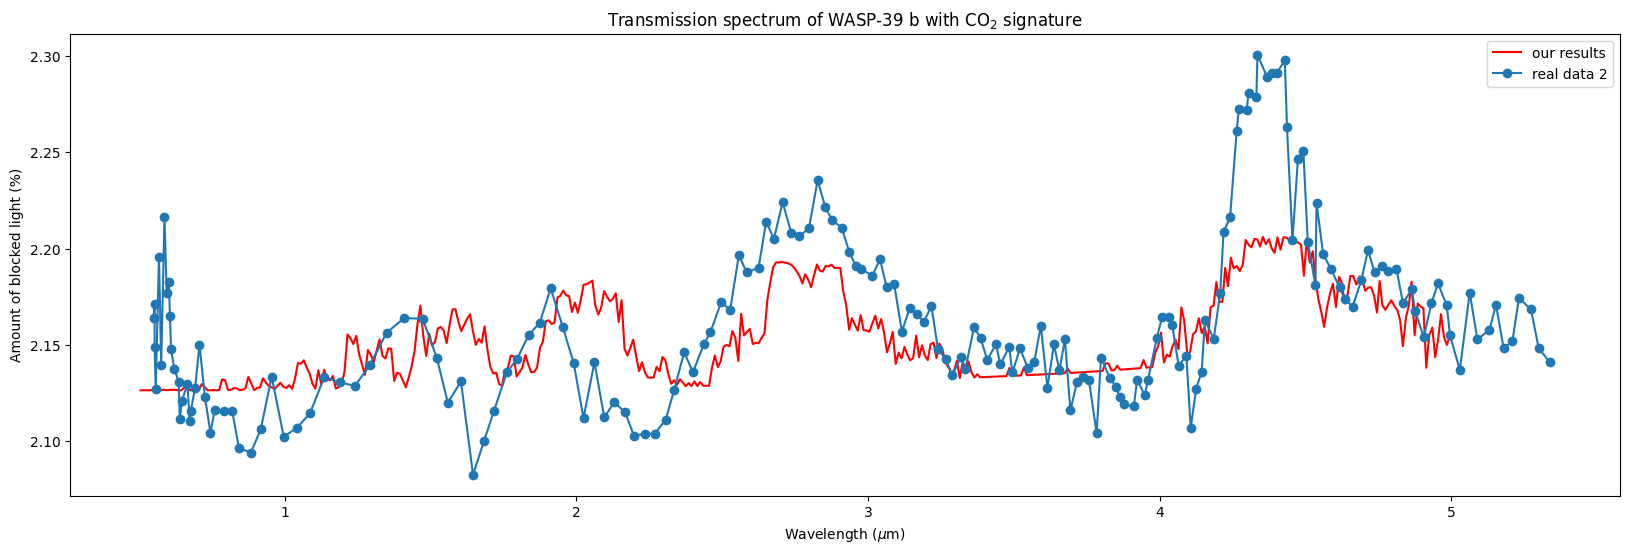

In [191]:
lambda_array = (const.c.value/freq_array)*1e6
print(len(lambda_array))
y = np.array(delta_nu)*100
print(len(y))
bin_size = 0.01
binned_data = fast_binning(lambda_array, y, bin_size)

observed_data = pd.read_csv('WASP39b_data_extended.csv')
observed_x = observed_data.iloc[:,0]
observed_y = observed_data.iloc[:,1]

plt.figure(figsize = (20,6))
plt.plot(binned_data[0], binned_data[1], label='our results', color = 'red')
# plt.plot(lambda_array, y, label='not binned')
plt.plot(observed_x, observed_y, 'o-', label='real data 2')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
# plt.grid(alpha = 0.2, linestyle = '--')
plt.savefig("transmission_spectrum_CO2_WASP39b.png")
plt.show()

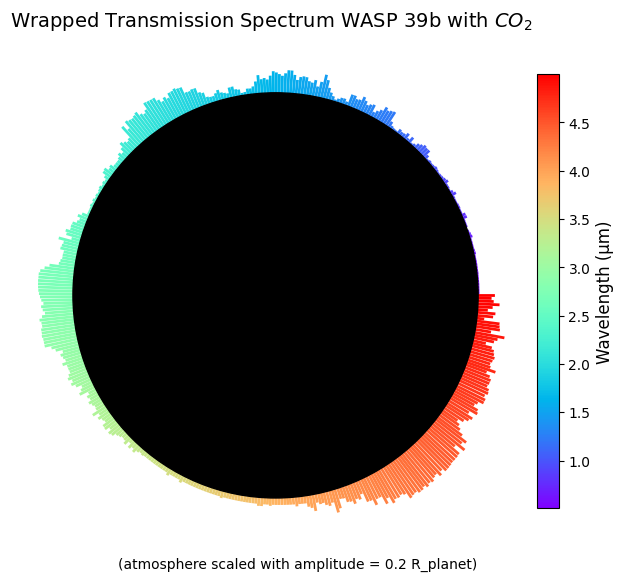

In [188]:
import matplotlib.cm as cm
import matplotlib.colors as colors

def wrap_curve_with_rainbow(x_array, y_array, Rp , amplitude):
    fig, ax = plt.subplots(figsize=(7, 7))
    theta = 2 * np.pi * (x_array - x_array.min()) / (x_array.max() - x_array.min())
    y_norm = (y_array - np.min(y_array)) / (np.max(y_array) - np.min(y_array))
    r = Rp + amplitude* y_norm

    X = r * np.cos(theta)
    Y = r * np.sin(theta)
    norm = colors.Normalize(vmin=x_array.min(), vmax=x_array.max())
    cmap = plt.colormaps["rainbow"]   # NEW API

    # sc = ax.scatter(X, Y, c=x_array, cmap=cmap, s=18)
        # ---- Plot radial lines ----
    for i in range(len(theta)):
        color = cmap(norm(x_array[i]))

        # Start at R0, end at r[i]
        x0 = Rp * np.cos(theta[i])
        y0 = Rp * np.sin(theta[i])
        x1 = r[i] * np.cos(theta[i])
        y1 = r[i] * np.sin(theta[i])

        ax.plot([x0, x1], [y0, y1], color=color, linewidth=2)

    planet = plt.Circle((0, 0), Rp, color="black", zorder=5)
    ax.add_patch(planet)

    # Keep circle shape
    ax.set_aspect("equal", "box")
    ax.axis("off")   # turn off AFTER creating ax

    # ---- Colorbar ----
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label("Wavelength (μm)", fontsize=12)


    ax.set_title(r"Wrapped Transmission Spectrum WASP 39b with $CO_2$", fontsize=14)
    fig.text(0.27, 0.1, f"(atmosphere scaled with amplitude = {amplitude/Rp} R_planet)", fontsize=10)



# ---- Example: replace with your real arrays ----
x = binned_data[0]
y = binned_data[1]
delta_arr = np.array(delta_nu)
# compute effective radius and atmospheric height
R_eff = np.array(R_star) * np.sqrt(binned_data[1])        # m
h_lambda = R_eff - np.array(R_p)      
wrap_curve_with_rainbow(x, h_lambda, R_p, 0.2*R_p)
# plt.savefig("wrapped_spectrum_CO2_WASP39b.png")
plt.show()
